# Predicting heart disease using machine learning
Building a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

  We're going to take the following approach:

    1.Problem definition
    2.Data Retrieval and Prepration
    3.Feature Extraction and Engineering
    4.Modeling
    5.Model Evaluation
    5.Experimentation (Prediction in Action)
### Problem Definition
In a statement,
> Given clinical parameters about a patient, can we predict whether or not they have heart disease?

### Data 

The original data came from the Cleavland data from the UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/heart+Disease

There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset

### Features

**Create data dictionary**

1. age - age in years
2. sex - (1 = male; 0 = female)
3. cp - chest pain type
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern
5. chol - serum cholestoral in mg/dl
    * serum = LDL + HDL + .2 * triglycerides
    * above 200 is cause for concern
6. fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
    * '>126' mg/dL signals diabetes
7. restecg - resting electrocardiographic results
    * 0: Nothing to note
    * 1: ST-T Wave abnormality
        * can range from mild symptoms to severe problems
        * signals non-normal heart beat
    * 2: Possible or definite left ventricular hypertrophy
        * Enlarged heart's main pumping chamber
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina (1 = yes; 0 = no)
10. oldpeak - ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more
11. slope - the slope of the peak exercise ST segment
    * 0: Upsloping: better heart rate with excercise (uncommon)
    * 1: Flatsloping: minimal change (typical healthy heart)
    * 2: Downslopins: signs of unhealthy heart
12. ca - number of major vessels (0-3) colored by flourosopy
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)
13. thal - thalium stress result
    * 1,3: normal
    * 6: fixed defect: used to be defect but ok now
    * 7: reversable defect: no proper blood movement when excercising
14. target - have disease or not (1=yes, 0=no) (= the predicted attribute)
    

## Preparing the tools

We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [21]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names*")

## 2. Data Retrieval and Prepration

## Load data 

In [2]:
df = pd.read_csv("008 heart-disease.csv")

In [5]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Exploration (exploratory data analysis or EDA)

In this process we are going to understand, summarize, and visualize the key characteristics of a dataset before building a machine learning model.




### Number Of Columns :

In [9]:
print("No.of columns " , {df.shape[1]})

No.of columns  {14}


### Number Of Rows :

In [12]:
print("No.of rows " , {df.shape[0]})

No.of rows  {303}


### Column Names :

In [15]:
print("Columns Names " , df.columns.values.tolist())

Columns Names  ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


### Missing Values Detection

In [18]:
print('Columns with null values:',df.columns[df.isnull().any()].tolist())
#rows with missing values
print('Columns with null values:',len(df.loc[df.isna().any(axis=1)]))

Columns with null values: []
Columns with null values: 0


### Identifying Row Indices with Missing Values :

In [21]:
RowIndicesComplete = df.loc[df.isna().any(axis=1)]
RowIndices = []
index = 1
end = len(RowIndicesComplete)
while index <= end:
    RowIndices.append(RowIndicesComplete[index-1:index].index[0])
    index = index + 1
print('Index with missing values:\n',RowIndices)

Index with missing values:
 []


### Dataset Structure and Summary Info

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Statistical Summary of Numerical Features

In [27]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Class Distribution of Target Variable
#### We are showing how many instances belong to each class (0 = no disease, 1 = disease) and visualizes them using a bar plot.

In [30]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

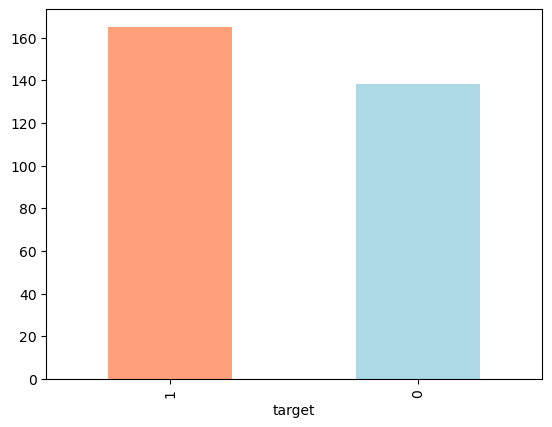

In [32]:
df["target"].value_counts().plot(kind="bar", color=["lightsalmon", "lightblue"])
plt.show()

###  Count of Missing Values per Column

In [34]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Age vs. Max Heart Rate for Heart Disease

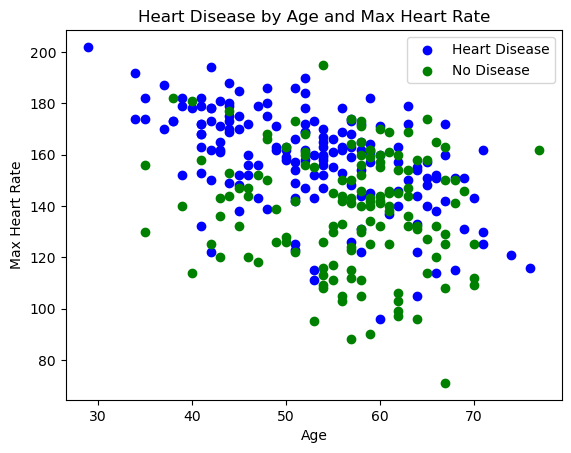

In [38]:

plt.scatter(df[df.target == 1]["age"], df[df.target == 1]["thalach"], color="blue")    # People with disease
plt.scatter(df[df.target == 0]["age"], df[df.target == 0]["thalach"], color="green")   # People without disease

# Labels and title
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Heart Disease by Age and Max Heart Rate")
plt.legend(["Heart Disease", "No Disease"])
plt.show()

### Histogram: Age Distribution of Patients

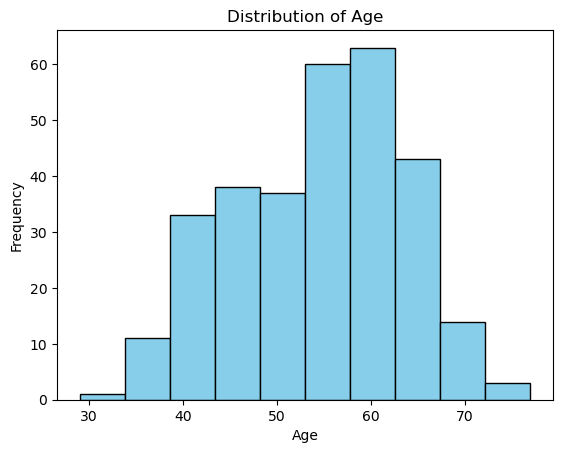

In [40]:

df['age'].plot.hist(bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Age")
plt.title("Distribution of Age")
plt.show()

### Heart Disease Frequency per Chest Pain Type

3. cp - chest pain type
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease

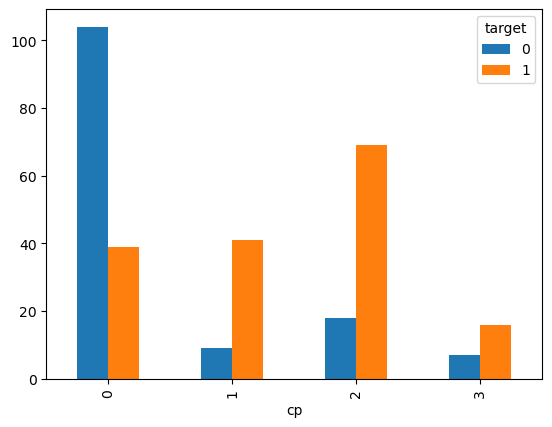

In [43]:

df.groupby("cp")["target"].value_counts().unstack().plot(kind="bar",)


plt.show()

In [45]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3.Feature Extraction and Engineering

In [49]:

Features = df.drop("target", axis=1)
Features


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [51]:
Labels = df["target"]
Labels

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

### Feature Transformation
#### > Scaling Data using Standard Scaler

In [54]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(Features)
Features_scaled = ss.transform(Features)
Features_scaled

array([[ 0.9521966 ,  0.68100522,  1.97312292, ..., -2.27457861,
        -0.71442887, -2.14887271],
       [-1.91531289,  0.68100522,  1.00257707, ..., -2.27457861,
        -0.71442887, -0.51292188],
       [-1.47415758, -1.46841752,  0.03203122, ...,  0.97635214,
        -0.71442887, -0.51292188],
       ...,
       [ 1.50364073,  0.68100522, -0.93851463, ..., -0.64911323,
         1.24459328,  1.12302895],
       [ 0.29046364,  0.68100522, -0.93851463, ..., -0.64911323,
         0.26508221,  1.12302895],
       [ 0.29046364, -1.46841752,  0.03203122, ..., -0.64911323,
         0.26508221, -0.51292188]])

### > Handling Missing Values in the Dataset

In [18]:
if df.isna().sum().sum() > 0:
    print("Missing values detected. Applying forward and backward fill...")

    # Apply forward fill
    df.fillna(method='ffill', inplace=True)
    
    # Apply backward fill
    df.fillna(method='bfill', inplace=True)
    
    print("Missing values after filling:\n", df.isna().sum())
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


### > Splitting the Dataset: Training and Testing Sets

In [20]:
from sklearn.model_selection import train_test_split

Features_train, Features_test, Labels_train, Labels_test = train_test_split(Features,Labels, test_size=0.2, random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(Features_train)
Features_train_scaled = ss.transform(Features_train)
Features_test_scaled = ss.transform(Features_test)

In [24]:

Features_train_scaled_df = pd.DataFrame(Features_train_scaled, columns=Features_train.columns)
Features_train_scaled_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-1.356798,0.722504,0.008099,-0.616856,0.914034,-0.383301,0.843133,0.532781,-0.676632,-0.920864,0.953905,-0.689701,-0.509048
1,0.385086,0.722504,-0.971891,1.169491,0.439527,-0.383301,-1.046109,-1.753582,1.477907,-0.193787,0.953905,-0.689701,1.178480
2,-0.921327,0.722504,0.988089,1.169491,-0.300704,-0.383301,0.843133,-0.139679,-0.676632,2.350982,-0.694988,-0.689701,-0.509048
3,0.058483,-1.384075,0.008099,0.276318,0.059921,-0.383301,-1.046109,0.487950,-0.676632,0.351521,-0.694988,-0.689701,-0.509048
4,0.602822,0.722504,-0.971891,-0.795490,-0.319684,2.608918,0.843133,0.443119,1.477907,0.351521,0.953905,1.333421,1.178480


## 4. Modeling

Now that we've **preprocessed** and **split our data** into training and test sets, the next important step is **Modeling**.

---

###  What is Modeling?

In simple terms, **modeling is the process of teaching our machine learning model how to understand the data**.

- We give the model a set of examples — the **training set**.
- The model learns the **patterns and relationships** between the input features and the target variable (e.g., whether someone has heart disease or not).
- After training, we evaluate the model’s performance using **new, unseen data** — the **test set**.

---

###  Why Try Multiple Models?

In real-world machine learning projects, we never rely on just one algorithm.

- **Different models may perform better** depending on the structure and nature of the dataset.
- By experimenting with **multiple algorithms**, we can **compare their performance** and choose the one that works best for our problem.

---


###  1. Logistic Regression
- This is a **basic yet powerful classification algorithm**.
- It works well when the output is binary, like **“disease” or “no disease.”**
- It's **fast, interpretable**, and often used as a **baseline model**.

---

###  2. Random Forest Classifier
- This is an **ensemble method** that builds **many decision trees** and combines their results.
- It helps **reduce overfitting** and increases **accuracy**.
- It's great at **handling mixed types of data** and performs well on our dataset.

---

###  3. Gradient Boosting Classifier
- Another powerful **ensemble technique**, but more advanced.
- It builds decision trees **one after another**, and each tree **fixes the errors** of the previous one.
- This model provides **very high performance**, especially on **structured/tabular data** like ours.

### 1. Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()    
log_reg.fit(Features_train_scaled, Labels_train)

LogisticRegression()

In [28]:
log_reg_pred = log_reg.predict(Features_test_scaled)
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(Labels_test, log_reg_pred)
print("Logistic Regression Accuracy Score:", accuracy_lr)

Logistic Regression Accuracy Score: 0.8524590163934426


### 2. Random Forest Classifier

In [30]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(Features_train, Labels_train)

RandomForestClassifier()

In [32]:
rf_pred = rf_clf.predict(Features_test)
accuracy_rf = accuracy_score(Labels_test, rf_pred)
print("Random Forest Accuracy Score:", accuracy_rf)

Random Forest Accuracy Score: 0.8524590163934426


### 3. Gradient Boosting

In [34]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
gb_clf = GradientBoostingClassifier()
gb_clf.fit(Features_train, Labels_train)

GradientBoostingClassifier()

In [36]:
gb_pred = gb_clf.predict(Features_test)
gb_aucc = accuracy_score(Labels_test, gb_pred)
print("Gradient Boosting Accuracy Score:", gb_aucc)

Gradient Boosting Accuracy Score: 0.7704918032786885


### Model Performance Comparison: Selecting the Best Classifier for Heart Disease Prediction

In [38]:
from sklearn.metrics import accuracy_score

log_reg_pred = log_reg.predict(Features_test_scaled)
rf_pred =rf_clf.predict(Features_test)
gb_pred = gb_clf.predict(Features_test)


log_reg_acc = accuracy_score(Labels_test, log_reg_pred)
rf_acc = accuracy_score(Labels_test, rf_pred)
gb_acc = accuracy_score(Labels_test, gb_pred)


model_scores = {
    "Logistic Regression": log_reg_acc,
    "Random Forest": rf_acc,
    "Gradient Boosting":gb_acc
}


for model, score in model_scores.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.8525
Random Forest: 0.8525
Gradient Boosting: 0.7705


### Which One Predicts Heart Disease Best?

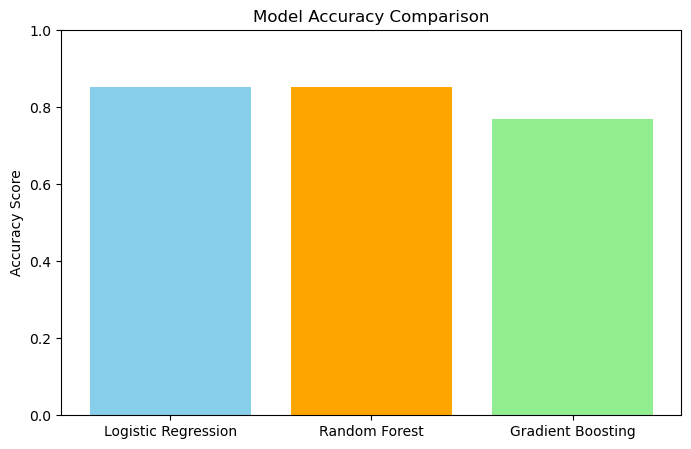

In [40]:

model_names = list(model_scores.keys())
scores = list(model_scores.values())

plt.figure(figsize=(8,5))
plt.bar(model_names, scores, color=['skyblue', 'orange','lightgreen'])
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

### Hyperparameter Tuning: Optimizing Model Performance

Now we are finding the best set of parameters for a machine learning model. These parameters are not learned from the data  instead, we set them manually before training.


In [109]:

log_reg_acc_before = model_scores["Logistic Regression"]
rf_acc_before = model_scores["Random Forest"]
gb_acc_before = model_scores["Gradient Boosting"]

In [42]:
log_reg_tuned = LogisticRegression(C=1.0, max_iter=500)
log_reg_tuned.fit(Features_train_scaled, Labels_train)
log_reg_acc_after = accuracy_score(Labels_test, log_reg_tuned.predict(Features_test_scaled))

rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_tuned.fit(Features_train, Labels_train)
rf_acc_after = accuracy_score(Labels_test, rf_tuned.predict(Features_test))

gb_tuned = GradientBoostingClassifier(n_estimators=300,learning_rate=0.85,max_depth=5,random_state=42)
gb_tuned.fit(Features_train, Labels_train)
gb_tuned_pred = gb_tuned.predict(Features_test)
gb_acc_after = accuracy_score(Labels_test, gb_tuned_pred)

print("Model Accuracies (after simple tuning):")
print(f"Logistic Regression: {log_reg_acc_after:.4f}")
print(f"Random Forest (depth=5): {rf_acc_after:.4f}")
print(f"Gradient Boosting (simple tuning) Accuracy: {gb_acc_after:.4f}")

Model Accuracies (after simple tuning):
Logistic Regression: 0.8525
Random Forest (depth=5): 0.8689
Gradient Boosting (simple tuning) Accuracy: 0.8197


### Accuracy Comparison: Before vs After Hyperparameter Tuning

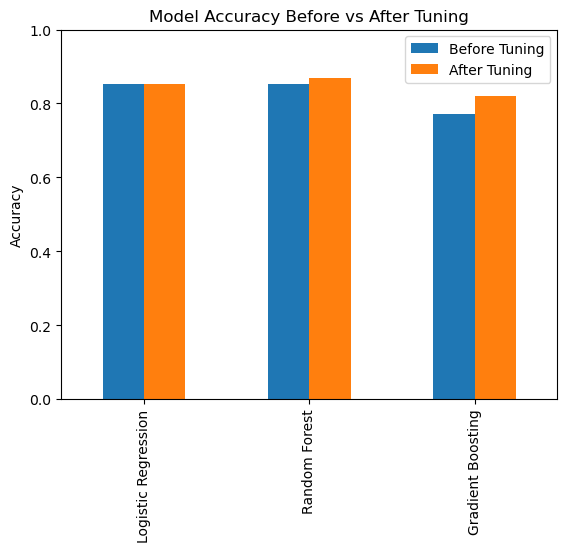

In [48]:
accuracy_data = {
    "Logistic Regression": [accuracy_lr, log_reg_acc_after],
    "Random Forest": [accuracy_rf, rf_acc_after],
    "Gradient Boosting": [gb_acc, gb_acc_after]
}

scores_df = pd.DataFrame(accuracy_data, index=["Before Tuning", "After Tuning"])

scores_df.T.plot(kind="bar")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Before vs After Tuning")
plt.ylim(0, 1)
plt.show()

## 5. Model Evaluation

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

... and it would be great if cross-validation was used where possible.

To make comparisons and evaluate our trained model, first we need to make predictions.

In [51]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_score, recall_score,
                             f1_score, accuracy_score)

### 1. Logistic Regression Evaluation :

In [53]:

log_reg_pred = log_reg.predict(Features_test_scaled)
log_reg_probs = log_reg.predict_proba(Features_test_scaled)[:, 1]


print(" Logistic Regression")
print("Accuracy:", accuracy_score(Labels_test, log_reg_pred))
print("Precision:", precision_score(Labels_test, log_reg_pred))
print("Recall:", recall_score(Labels_test, log_reg_pred))
print("F1 Score:", f1_score(Labels_test, log_reg_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Labels_test, log_reg_pred))
print("\nClassification Report:\n", classification_report(Labels_test, log_reg_pred))


 Logistic Regression
Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1 Score: 0.8571428571428571

Confusion Matrix:
 [[25  4]
 [ 5 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



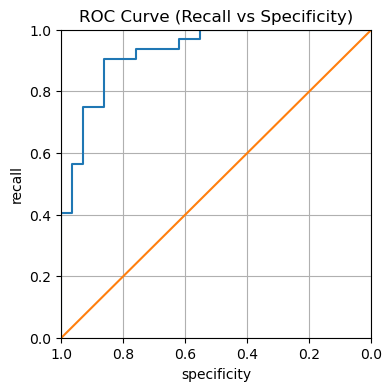

In [126]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(Labels_test, log_reg.predict_proba(Features_test_scaled)[:, 1])

roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

# Plot ROC with specificity on x-axis and recall on y-axis
ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)  # Reverse x-axis for specificity
ax.plot((1, 0), (0, 1))  # Diagonal reference line
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
plt.title("ROC Curve (Recall vs Specificity)")
plt.grid()
plt.show()

### 2. Random Forest Evaluation


In [128]:

rf_pred = rf_clf.predict(Features_test.values)
rf_probs = rf_clf.predict_proba(Features_test.values)[:, 1]

print(" Random Forest")
print("Accuracy:", accuracy_score(Labels_test, rf_pred))
print("Precision:", precision_score(Labels_test, rf_pred))
print("Recall:", recall_score(Labels_test, rf_pred))
print("F1 Score:", f1_score(Labels_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Labels_test, rf_pred))
print("\nClassification Report:\n", classification_report(Labels_test, rf_pred))


 Random Forest
Accuracy: 0.7213114754098361
Precision: 0.8947368421052632
Recall: 0.53125
F1 Score: 0.6666666666666666

Confusion Matrix:
 [[27  2]
 [15 17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.93      0.76        29
           1       0.89      0.53      0.67        32

    accuracy                           0.72        61
   macro avg       0.77      0.73      0.71        61
weighted avg       0.77      0.72      0.71        61



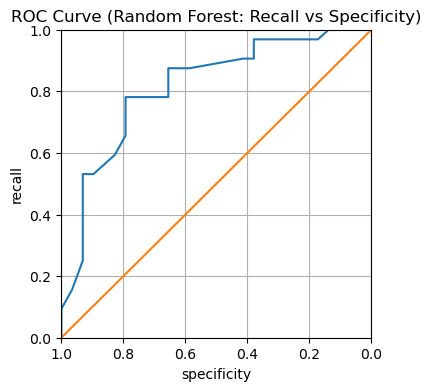

In [159]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(Labels_test, rf_probs)

roc_df_rf = pd.DataFrame({'recall': tpr_rf, 'specificity': 1 - fpr_rf})

# Plot ROC with specificity on x-axis and recall on y-axis
ax = roc_df_rf.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)  # Reverse x-axis for specificity
ax.plot((1, 0), (0, 1))  # Diagonal reference line
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
plt.title("ROC Curve (Random Forest: Recall vs Specificity)")
plt.grid()
plt.show()

### 3. Gradient Boosting

In [130]:
gb_clf.fit(Features_train, Labels_train)  
gb_pred = gb_clf.predict(Features_test)
gb_probs = gb_clf.predict_proba(Features_test)[:, 1]

print("\n Gradient Boosting")
print("Accuracy:", accuracy_score(Labels_test, gb_pred))
print("Precision:", precision_score(Labels_test, gb_pred))
print("Recall:", recall_score(Labels_test, gb_pred))
print("F1 Score:", f1_score(Labels_test, gb_pred))

print("\nConfusion Matrix:\n", confusion_matrix(Labels_test, gb_pred))
print("\nClassification Report:\n", classification_report(Labels_test, gb_pred))



 Gradient Boosting
Accuracy: 0.7704918032786885
Precision: 0.8
Recall: 0.75
F1 Score: 0.7741935483870968

Confusion Matrix:
 [[23  6]
 [ 8 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.77        29
           1       0.80      0.75      0.77        32

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



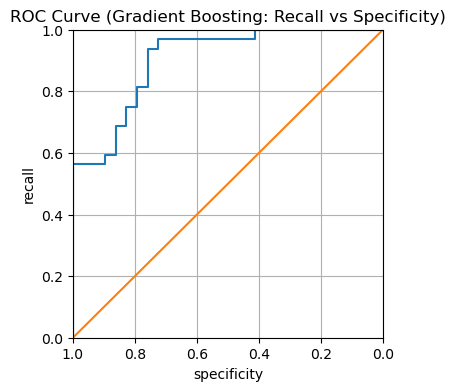

In [132]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve(Labels_test, gb_probs)

# Create DataFrame for plotting
roc_df_gb = pd.DataFrame({'recall': tpr_gb, 'specificity': 1 - fpr_gb})

# Plot ROC Curve: specificity vs recall
ax = roc_df_gb.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)  # Reverse x-axis to represent specificity
ax.plot((1, 0), (0, 1))  # Reference diagonal line
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
plt.title("ROC Curve (Gradient Boosting: Recall vs Specificity)")
plt.grid()
plt.show()

### Feature Importance

Feature importance is another as asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance".

We find the feature importance for our  models ...

### 1. Logistic Regression (using coefficients)

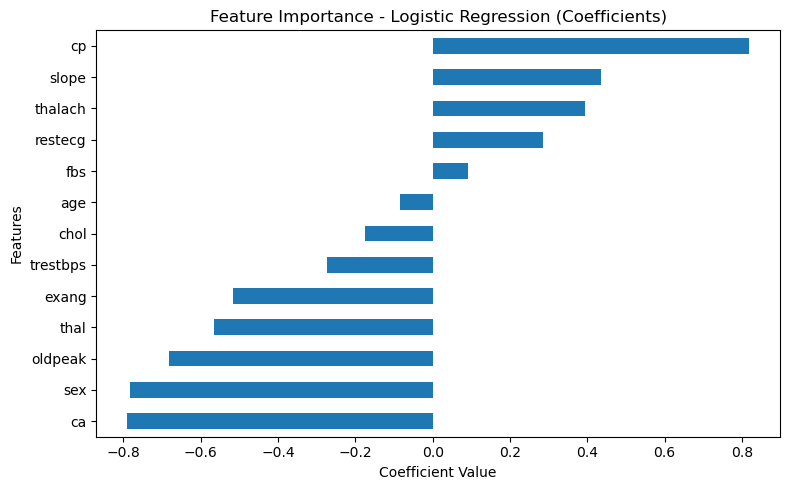

In [95]:
# Coefficients as importance
importance = log_reg.coef_[0]  # array of coefficients
feature_names = Features_train.columns
# Plot
feat_importance = pd.Series(importance, index= feature_names)
feat_importance.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance - Logistic Regression (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### 2. Random Forest

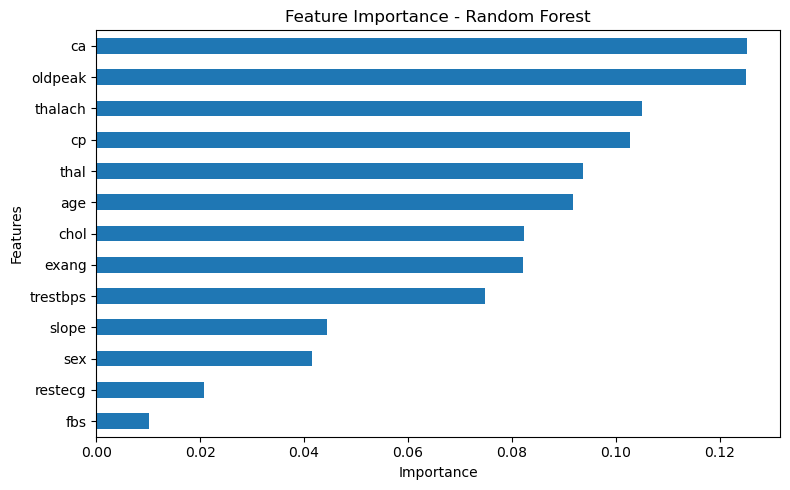

In [96]:
# Get feature importances
importances = rf_clf.feature_importances_

# Visualize
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your features are in a DataFrame
feature_names = Features_train.columns  # if you used a DataFrame
feat_importance = pd.Series(importances, index=feature_names)

# Plot
feat_importance.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### Saving the Model

In [55]:
import joblib
import os

if not os.path.exists('Models'):os.mkdir('Models')

if not os.path.exists('Scalers'):os.mkdir('Scalers')



In [57]:

joblib.dump(ss, r'Scalers/scalers.pickel')

joblib.dump(gb_clf, r'Models/Gradient-Boosting_odel.pickel')
joblib.dump(log_reg, r'Models/logistic_regression_model.pickel')
joblib.dump(rf_clf, r'Models/random_forest_model.pickel')

['Models/random_forest_model.pickel']

#   Heart Disease Prediction — Experimentation Summary

---

## 1. Models Compared

| Model                | Description                                      | Accuracy (Before Tuning) | Accuracy (After Tuning)                      |
|----------------------|--------------------------------------------------|---------------------------|----------------------------------------------|
| Logistic Regression  | Simple, interpretable baseline                   | 0.8525                    | 0.8525 (with `C=1.0`, `max_iter=500`)        |
| Random Forest        | Ensemble model, robust performance               | 0.8525                    | 0.8689 (with `n_estimators=100`, `max_depth=5`)  |
| Gradient Boosting    | Sequential ensemble, reduces bias progressively  | 0.7869                    | 0.8197 (with `n_estimators=300`, `learning_rate=0.85`, `max_depth=5`) |



---

##  2. Preprocessing Steps 

| Step                        | Result/Impact                                       |
|-----------------------------|----------------------------------------------------|
| Scaling with StandardScaler | Helped improve model convergence & performance     |
| Handling missing values     | Cleaned dataset — no major missing values handled  |

---

##  3. Evaluation Metrics Used

| Metric             | Purpose                              | Observations                                  |
|--------------------|---------------------------------------|-----------------------------------------------|
| Accuracy           | Overall prediction correctness        | Improved after tuning for RF & GB             |
| Precision & Recall | False positive/negative evaluation    | Balanced across models post-tuning            |
| F1-Score           | Harmonic mean of Precision & Recall   | Gradient Boosting improved after tuning       |
| ROC-AUC            | Probability-based discrimination      | Best in Random Forest                         |
| Confusion Matrix   | Class-wise prediction visualization   | Helped assess true/false positives & negatives|


##  4. Feature Importance
| Model             | Use of Feature Importance  | Key Features Identified             |
|-------------------|-----------------------------|-------------------------------------|
| Random Forest      | Yes (feature_importances_)  | `cp`, `thalach`, `ca`, `exang`      |
| Logistic Regression| Yes (via coefficients)      | Similar to Random Forest            |
| Gradient Boosting  | Yes                         | `cp`, `ca`, `thalach`, `oldpeak`    |


##  5. Hyperparameter Tuning

| Model               | Tuning Method Used     | Best Parameters Found                              |
|---------------------|------------------------|----------------------------------------------------|
| Random Forest        | Manual tuning          | `n_estimators=100`, `max_depth=5`                  |
| Logistic Regression  | Manual tuning          | `C=1.0`, `max_iter=500`                            |
| Gradient Boosting    | Manual tuning          | `n_estimators=300`, `learning_rate=0.85`, `max_depth=5` |

# 6. What Worked Best?

-  **Random Forest (after tuning)** achieved the **highest accuracy (0.8689)**.
-  **Gradient Boosting** showed improvement with tuning, reaching **0.8197** accuracy.
-  **Logistic Regression** maintained a consistent baseline accuracy of **0.8525**.
-  Evaluation using **ROC-AUC**, **Classification Report**, and **Confusion Matrix** provided valuable insights.
-  Models were saved using `joblib` for future reuse and deployment.